
* Final Project Appendix

* Markdown File


# Predicting Electric Fleet Suitability for U.S. Businesses

This notebook uses the NREL Fleet DNA dataset to build and compare classification models for EV suitability. The analysis focuses on daily distance, speed, driving time, stop activity, and vehicle characteristics.

The goal is to identify operating patterns that can help fleet managers decide which vehicles should receive a deeper electrification review.

This is a supplement to the Write up and Presentation and contains the top level information to support those mediums. 

## Step 1: Load and Inspect the Fleet DNA Data

The Fleet DNA dataset is loaded and reviewed for overall structure.

Output: The dataset contains 4,705 vehicle-day records and 372 columns. A small preview and data type summary are shown below.

In [19]:
#Import libraries
from pathlib import Path
import pandas as pd
import numpy as np

#Find Fleet DNA file
data_files = (
    list(Path(".").glob("*.csv")) +
    list(Path(".").glob("*.xlsx")) +
    list(Path(".").glob("*.xls"))
)

file_path = next(
    (
        file for file in data_files
        if "fleet" in file.name.lower() or "dna" in file.name.lower()
    ),
    None
)

if file_path is None:
    raise FileNotFoundError(
        "No Fleet DNA file was found. Put the Fleet DNA file in this folder."
    )

#Load dataset
if file_path.suffix.lower() == ".csv":
    fleet = pd.read_csv(file_path)
else:
    fleet = pd.read_excel(file_path)

#Output basic dataset structure
print(f"Loaded file: {file_path.name}")
print(f"Dataset shape: {fleet.shape}")

print("\nFirst three rows:")
display(fleet.head(3))

print("\nData type summary:")
display(
    fleet.dtypes.value_counts()
    .rename_axis("Data_Type")
    .reset_index(name="Count")
)

Loaded file: data_for_fleet_dna_composite_data.csv
Dataset shape: (4705, 372)

First three rows:


,vid,did,pid,class_id,voc_id,type_id,drive_id,fuel_id,day_id,trip_count,...,spd_cat_7_distance,spd_cat_7_mean_speed,spd_cat_7_std_speed,spd_cat_7_ttl,spd_cat_7_zero_speed,spd_cat_8_distance,spd_cat_8_mean_speed,spd_cat_8_std_speed,spd_cat_8_ttl,spd_cat_8_zero_speed
0,236,25,17,7,10,5,0,1,260,4,...,0.0,NaN,NaN,0,0,0.0,NaN,NaN,0,0
1,236,25,17,7,10,5,0,1,262,1,...,0.0,NaN,NaN,0,0,0.0,NaN,NaN,0,0
2,236,25,17,7,10,5,0,1,263,5,...,0.0,NaN,NaN,0,0,0.0,NaN,NaN,0,0



Data type summary:


,Data_Type,Count
0,float64,329
1,int64,41
2,str,2


## Step 2: Review Missing Values and Data Quality

Missing values and key category fields are reviewed before selecting variables for modeling.

Output: Most columns are complete, including 342 with no missing values. The dataset also contains 486 vehicles, 57 deployments, and multiple vehicle classes, vocations, drivetrains, and fuel types.

In [20]:
#Calculate missing values
missing_summary = pd.DataFrame({
    "Column": fleet.columns,
    "Missing_Count": fleet.isna().sum().values,
    "Missing_Percent": (fleet.isna().mean().values * 100).round(2)
})

#Create missing-value groups
missing_groups = pd.cut(
    missing_summary["Missing_Percent"],
    bins=[-1, 0, 25, 50, 75, 100],
    labels=["0%", "1-25%", "26-50%", "51-75%", "76-100%"]
)

missing_group_summary = (
    missing_groups.value_counts()
    .sort_index()
    .rename_axis("Missing_Percent_Group")
    .reset_index(name="Column_Count")
)

#Output missing-value summary
print("Missing value summary:")
display(missing_group_summary)

#Output five columns with highest missingness
print("\nTop five columns by missing percentage:")
display(
    missing_summary
    .sort_values("Missing_Percent", ascending=False)
    .head(5)
)

#Summarize identifier and category fields
category_cols = [
    "vid", "did", "pid", "class_id",
    "voc_id", "type_id", "drive_id", "fuel_id"
]

category_summary = pd.DataFrame({
    "Column": category_cols,
    "Unique_Values": [
        fleet[col].nunique(dropna=True)
        for col in category_cols
    ]
})

print("\nCategory and ID field summary:")
display(category_summary)

Missing value summary:


,Missing_Percent_Group,Column_Count
0,0%,342
1,1-25%,14
2,26-50%,2
3,51-75%,6
4,76-100%,8



Top five columns by missing percentage:


,Column,Missing_Count,Missing_Percent
359,spd_cat_6_std_speed,4705,100.0
369,spd_cat_8_std_speed,4705,100.0
368,spd_cat_8_mean_speed,4705,100.0
364,spd_cat_7_std_speed,4705,100.0
363,spd_cat_7_mean_speed,4705,100.0



Category and ID field summary:


,Column,Unique_Values
0,vid,486
1,did,57
2,pid,20
3,class_id,7
4,voc_id,11
5,type_id,9
6,drive_id,4
7,fuel_id,3


## Step 3: Review Candidate Modeling Variables

Candidate variables are reviewed to identify the fields most relevant to EV suitability.

Output: The selected variables cover distance, trips, driving time, speed, stop activity, and vehicle characteristics.

In [21]:
#Select candidate modeling variables
candidate_model_columns = [
    "distance_total",
    "trip_count",
    "driving_data_duration_hrs",
    "speed_data_duration_hrs",
    "driving_average_speed",
    "max_speed",
    "percent_zero",
    "total_stops",
    "stops_per_mile",
    "average_stop_duration",
    "class_id",
    "voc_id",
    "type_id",
    "drive_id",
    "fuel_id"
]

#Summarize selected variables
candidate_summary = pd.DataFrame({
    "Variable": candidate_model_columns,
    "Data_Type": [
        str(fleet[col].dtype)
        for col in candidate_model_columns
    ],
    "Missing_Percent": [
        round(fleet[col].isna().mean() * 100, 2)
        for col in candidate_model_columns
    ]
})

print("Selected candidate modeling variables:")
display(candidate_summary)

Selected candidate modeling variables:


,Variable,Data_Type,Missing_Percent
0,distance_total,float64,0.0
1,trip_count,int64,0.0
2,driving_data_duration_hrs,float64,0.0
3,speed_data_duration_hrs,float64,0.0
4,driving_average_speed,float64,0.0
5,max_speed,float64,0.0
6,percent_zero,float64,0.0
7,total_stops,float64,0.0
8,stops_per_mile,float64,0.0
9,average_stop_duration,float64,0.0


## Step 4: Create a Focused Modeling Dataset

The selected fields are combined into the final modeling dataset.

Output: The focused dataset contains 4,705 rows and 19 columns with no missing values in the selected fields. Average daily distance is 70.05 miles, with 8.81 trips, 2.60 driving hours, and 109.47 stops per vehicle-day.

In [22]:
#Select identifier columns
id_columns = [
    "vid",
    "did",
    "pid",
    "day_id"
]

#Select modeling columns
model_columns = [
    "distance_total",
    "trip_count",
    "driving_data_duration_hrs",
    "speed_data_duration_hrs",
    "driving_average_speed",
    "max_speed",
    "percent_zero",
    "total_stops",
    "stops_per_mile",
    "average_stop_duration",
    "class_id",
    "voc_id",
    "type_id",
    "drive_id",
    "fuel_id"
]

#Create focused modeling dataset
model_data = fleet[id_columns + model_columns].copy()

#Replace infinite values with missing values
model_data = model_data.replace([np.inf, -np.inf], np.nan)

#Output dataset shape
print("Focused modeling dataset shape:", model_data.shape)

#Preview top records
print("\nFirst three rows:")
display(model_data.head(3))

#Check selected fields for missing values
selected_missing = pd.DataFrame({
    "Column": model_data.columns,
    "Missing_Count": model_data.isna().sum().values
})

print("\nColumns with missing values:")
missing_selected = selected_missing[
    selected_missing["Missing_Count"] > 0
]

if missing_selected.empty:
    print("No missing values found in the selected modeling fields.")
else:
    display(missing_selected)

#Summarize key operational fields
summary_columns = [
    "distance_total",
    "trip_count",
    "driving_data_duration_hrs",
    "driving_average_speed",
    "percent_zero",
    "total_stops",
    "stops_per_mile"
]

print("\nKey operational summary statistics:")
display(
    model_data[summary_columns]
    .describe()
    .T[["mean", "50%", "min", "max"]]
    .rename(columns={"50%": "median"})
    .round(2)
)

Focused modeling dataset shape: (4705, 19)

First three rows:


,vid,did,pid,day_id,distance_total,trip_count,driving_data_duration_hrs,speed_data_duration_hrs,driving_average_speed,max_speed,percent_zero,total_stops,stops_per_mile,average_stop_duration,class_id,voc_id,type_id,drive_id,fuel_id
0,236,25,17,260,172.913326,4,7.902778,18.435556,21.880069,61.244115,57.132956,317.0,1.833288,121.340063,7,10,5,0,1
1,236,25,17,262,22.292786,1,1.855833,2.993889,12.012278,32.082775,38.012618,69.0,3.095172,59.347826,7,10,5,0,1
2,236,25,17,263,87.400215,5,3.146667,10.555000,27.775492,66.238112,70.187905,111.0,1.270020,384.340541,7,10,5,0,1



Columns with missing values:
No missing values found in the selected modeling fields.

Key operational summary statistics:


,mean,median,min,max
distance_total,70.05,56.66,5.13,568.27
trip_count,8.81,8.00,1.00,40.00
driving_data_duration_hrs,2.60,2.25,0.18,13.80
driving_average_speed,26.16,24.17,8.45,54.48
percent_zero,43.18,43.78,0.69,95.33
total_stops,109.47,80.00,2.00,825.00
stops_per_mile,2.01,1.45,0.06,16.75


## Step 5: Create an EV Suitability Label

A rule-based target is created using mileage, driving time, average speed, stop-and-go activity, and active route use.

Output: Vehicle-days meeting at least 4 of the 5 rules are classified as High Suitability. The final target includes 3,481 High Suitability records (73.99%) and 1,224 Not High Suitability records (26.01%).

In [23]:
#Output cleaning results
print(
    "Negative average stop duration values cleaned:",
    negative_stop_count
)

print(
    "Average stop duration 99th percentile cap:",
    round(stop_duration_cap, 2)
)

#Output suitability rule counts
rule_summary = (
    model_ready[score_columns]
    .sum()
    .rename_axis("Rule")
    .reset_index(name="Vehicle_Day_Count")
)

print("\nSuitability rule counts:")
display(rule_summary)

#Output target distribution
target_distribution = (
    model_ready["ev_suitability_label"]
    .value_counts()
    .rename_axis("EV_Suitability_Label")
    .reset_index(name="Count")
)

target_distribution["Percent"] = (
    target_distribution["Count"] /
    len(model_ready) * 100
).round(2)

print("\nEV suitability target distribution:")
display(target_distribution)

Negative average stop duration values cleaned: 261
Average stop duration 99th percentile cap: 2846.05

Suitability rule counts:


,Rule,Vehicle_Day_Count
0,manageable_distance,3681
1,moderate_driving_time,4565
2,local_speed_pattern,3911
3,stop_go_pattern,3965
4,active_route,3358



EV suitability target distribution:


,EV_Suitability_Label,Count,Percent
0,High Suitability,3481,73.99
1,Not High Suitability,1224,26.01


## Step 6: Build and Evaluate a Decision Tree Model

The first classification model is a Decision Tree using the selected operating and vehicle characteristics.

Output: The model performs well on the test data, with about 95.3% accuracy. The detailed metrics and confusion matrix are shown below.

In [24]:
#Create Decision Tree evaluation summary
decision_tree_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

decision_tree_results["Score"] = (
    decision_tree_results["Score"].round(4)
)

#Output training and test sizes
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

#Output evaluation metrics
print("\nDecision Tree Evaluation:")
display(decision_tree_results)

#Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual Not High", "Actual High"],
    columns=["Predicted Not High", "Predicted High"]
)

print("\nDecision Tree Confusion Matrix:")
display(conf_matrix_df)

Training rows: 3528
Test rows: 1177

Decision Tree Evaluation:


,Metric,Score
0,Accuracy,0.9533
1,Precision,0.9939
2,Recall,0.9426
3,F1 Score,0.9676



Decision Tree Confusion Matrix:


,Predicted Not High,Predicted High
Actual Not High,301,5
Actual High,50,821


## Step 7: Interpret the Decision Tree Model

Feature importance is used to identify which variables contribute most to the Decision Tree predictions.

Output: Average speed, total stops, and daily distance are the strongest predictors. The pattern favors lower-speed, stop-heavy, moderate-distance vehicle use.

In [26]:
#Get Decision Tree feature importance
dt_model = decision_tree_model.named_steps["model"]

dt_features = decision_tree_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": dt_features,
    "Importance": dt_model.feature_importances_
})

#Clean feature names
importance_df["Feature"] = importance_df["Feature"].str.replace(
    r"^(cat__|num__)",
    "",
    regex=True
)

#Output top five Decision Tree features
print("Top Decision Tree feature importances:")

display(
    importance_df
    .sort_values("Importance", ascending=False)
    .head(5)
    .round(4)
)

Top Decision Tree feature importances:


,Feature,Importance
38,driving_average_speed,0.3962
41,total_stops,0.3101
34,distance_total,0.2409
40,percent_zero,0.0287
35,trip_count,0.0154


## Step 8: Build and Evaluate a Random Forest Model

A Random Forest is built as a comparison to the Decision Tree.

Output: The Random Forest performs slightly better overall, with about 95.4% accuracy and the best balance of accuracy, recall, and F1-score.

In [25]:
#Create Random Forest evaluation summary
random_forest_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

random_forest_results["Score"] = (
    random_forest_results["Score"].round(4)
)

#Output evaluation metrics
print("Random Forest Evaluation:")
display(random_forest_results)

#Create confusion matrix
rf_conf_matrix = confusion_matrix(y_test, rf_pred)

rf_conf_matrix_df = pd.DataFrame(
    rf_conf_matrix,
    index=["Actual Not High", "Actual High"],
    columns=["Predicted Not High", "Predicted High"]
)

print("\nRandom Forest Confusion Matrix:")
display(rf_conf_matrix_df)

Random Forest Evaluation:


,Metric,Score
0,Accuracy,0.9541
1,Precision,0.9904
2,Recall,0.9472
3,F1 Score,0.9683



Random Forest Confusion Matrix:


,Predicted Not High,Predicted High
Actual Not High,298,8
Actual High,46,825


## Step 9: Compare Model Performance

The two models are compared across accuracy, precision, recall, and F1-score.

Output: Performance is very similar, but the Random Forest has slightly higher accuracy, recall, and F1-score.

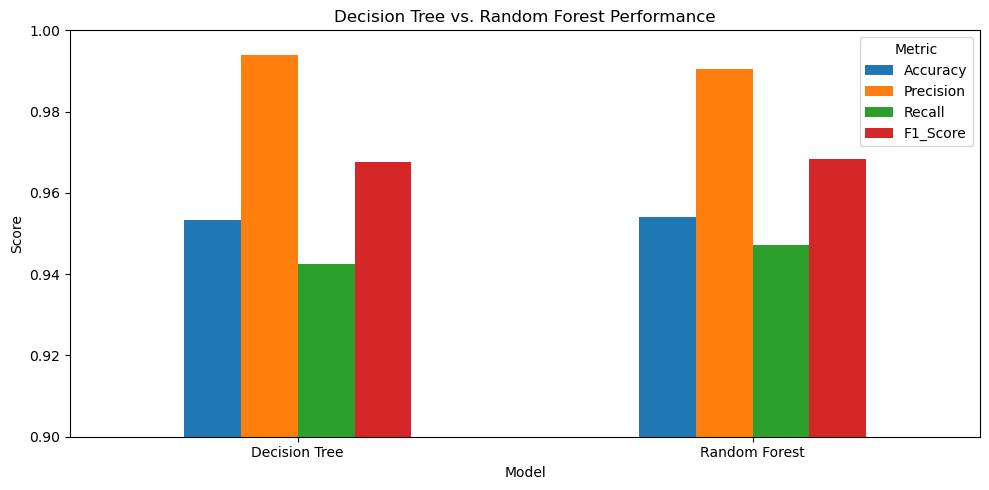

In [13]:
#Create model comparison chart
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Decision Tree vs. Random Forest Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

#Output model comparison
plt.show()

## Step 10: Interpret Random Forest Feature Importance

Feature importance is reviewed for the Random Forest.

Output: Average speed, total stops, and daily distance are among the strongest predictors, with additional importance spread across several operating variables.

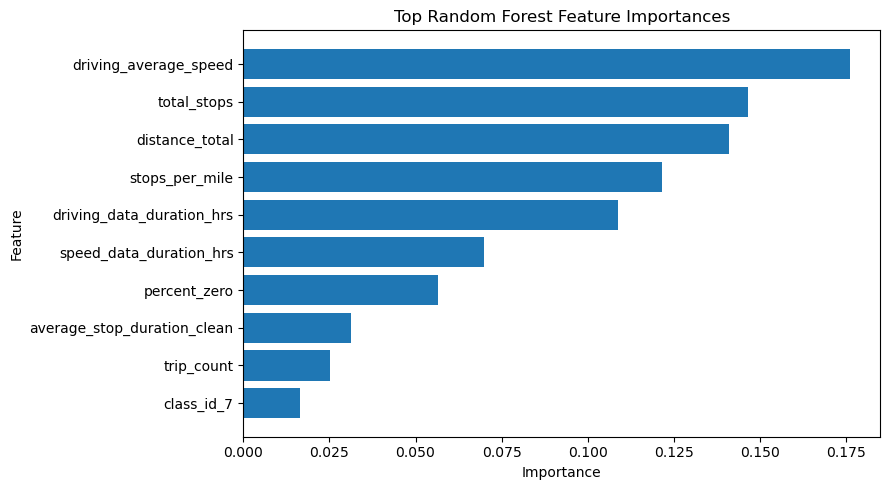

In [14]:
#Get fitted Random Forest and feature names
rf_model = random_forest_model.named_steps["model"]
rf_features = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

#Create feature importance dataframe
rf_importance = pd.DataFrame({
    "Feature": rf_features,
    "Importance": rf_model.feature_importances_
})

#Clean feature names
rf_importance["Feature"] = rf_importance["Feature"].str.replace(
    r"^(cat__|num__)", "", regex=True
)

#Sort feature importance
rf_importance = rf_importance.sort_values(
    "Importance", ascending=False
)

#Create Random Forest feature importance chart
top_rf_importance = rf_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 5))
plt.barh(
    top_rf_importance["Feature"],
    top_rf_importance["Importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

#Output feature importance
plt.show()

## Step 11: Compare Feature Importance Between Models

This step compares the two models.

Output: Both models identify speed, stops, and distance as the main operating factors associated with EV suitability.

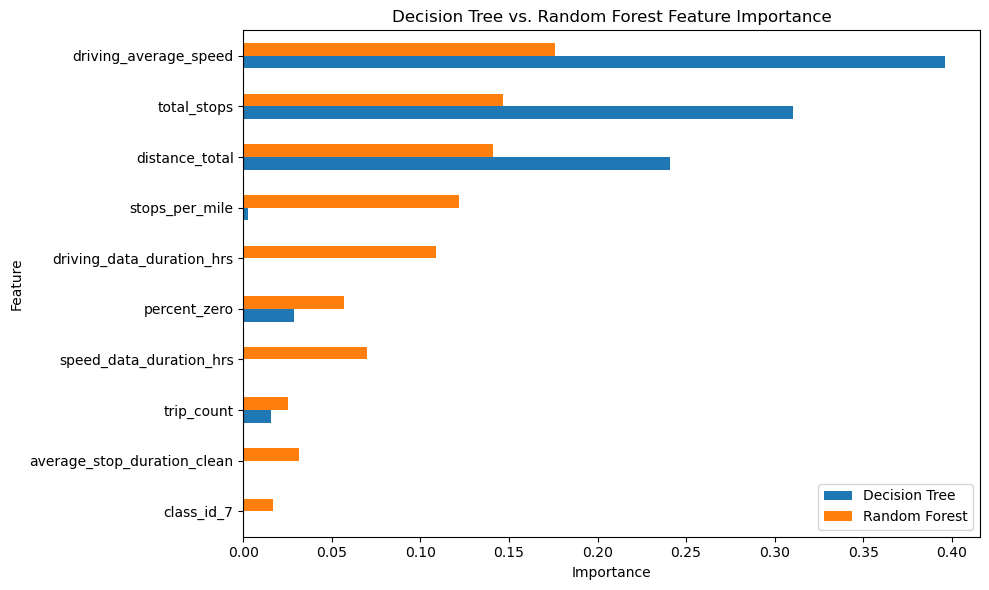

In [15]:
#Get Decision Tree feature importance
dt_model = decision_tree_model.named_steps["model"]
dt_features = decision_tree_model.named_steps[
    "preprocessor"
].get_feature_names_out()

dt_importance = pd.DataFrame({
    "Feature": dt_features,
    "Decision Tree": dt_model.feature_importances_
})

#Clean feature names
dt_importance["Feature"] = dt_importance["Feature"].str.replace(
    r"^(cat__|num__)", "", regex=True
)

#Prepare Random Forest importance
rf_compare = rf_importance[
    ["Feature", "Importance"]
].rename(columns={"Importance": "Random Forest"})

#Combine model importances
feature_comparison = dt_importance.merge(
    rf_compare,
    on="Feature",
    how="outer"
).fillna(0)

#Select most important features overall
feature_comparison["Combined"] = (
    feature_comparison["Decision Tree"] +
    feature_comparison["Random Forest"]
)

top_features = (
    feature_comparison
    .sort_values("Combined", ascending=False)
    .head(10)
    .sort_values("Combined")
)

#Create comparison chart
top_features.set_index("Feature")[
    ["Decision Tree", "Random Forest"]
].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Decision Tree vs. Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

#Output feature comparison
plt.show()

## Step 12: Visualize the Random Forest Confusion Matrix

A confusion matrix visual is created.

**Output:** Most predictions are correct, with 8 false positives and 46 false negatives.

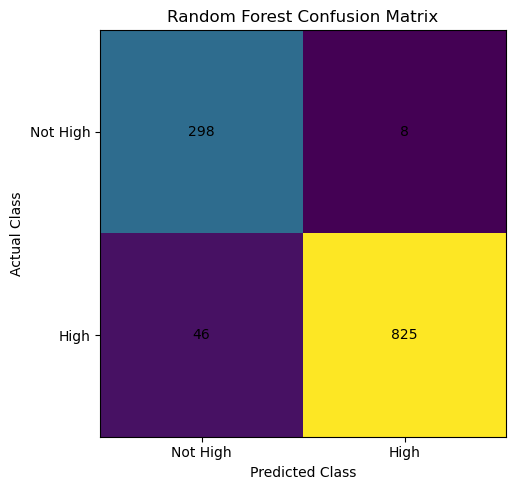

In [17]:
#Create Random Forest confusion matrix
rf_conf_matrix = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
plt.imshow(rf_conf_matrix)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Not High", "High"]
)

plt.yticks(
    [0, 1],
    ["Not High", "High"]
)

#Add values to matrix
for i in range(rf_conf_matrix.shape[0]):
    for j in range(rf_conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            rf_conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

#Output confusion matrix
plt.show()

## Step 13: Select the Final Model

The final model is selected based on overall predictive performance and usefulness for the business problem.

Decision: Random Forest is selected because it provides the best overall balance of accuracy, recall, and F1-score.

## Step 14: Define a Strong EV Candidate

The final comparison translates the model results into a practical fleet profile.

Output: Stronger candidates generally have moderate daily mileage, lower average speeds, and frequent stop-and-go activity.

In [27]:
#Compare key operating patterns by suitability
candidate_profile = model_ready.groupby(
    "ev_suitability_label"
)[
    [
        "distance_total",
        "driving_average_speed",
        "percent_zero",
        "total_stops",
        "stops_per_mile"
    ]
].median().round(2)

#Rename columns for cleaner output
candidate_profile.columns = [
    "Daily_Miles",
    "Average_Speed",
    "Percent_Zero",
    "Total_Stops",
    "Stops_Per_Mile"
]

#Output candidate profile
display(candidate_profile)

,Daily_Miles,Average_Speed,Percent_Zero,Total_Stops,Stops_Per_Mile
ev_suitability_label,,,,,
High Suitability,54.39,23.02,47.52,92.0,1.65
Not High Suitability,95.25,36.58,26.08,29.0,0.57


## Conclusion

The model should be used as a screening tool rather than an automatic replacement decision. The suitability target is rule-based and does not include financial, charging, incentive, or payback factors.

Fleet managers should prioritize vehicles with moderate daily mileage, lower-speed operation, and frequent stop activity for a deeper EV review.